In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datathon-alicorp-2023-b/submit_example.csv
/kaggle/input/datathon-alicorp-2023-b/RentabilidadProduct.csv
/kaggle/input/datathon-alicorp-2023-b/train.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
train = pd.read_csv('/kaggle/input/datathon-alicorp-2023-b/RentabilidadProduct.csv')
train.head()

,product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf
0,881|1291|20|131|4|10.37801657
1,805|1224|20|131|3|10.17792519
2,892|1089|20|146|1|10.00824289
3,841|1224|20|131|3|7.698361552
4,830|1089|20|131|1|7.35367762


In [4]:
test = pd.read_csv('/kaggle/input/datathon-alicorp-2023-b/submit_example.csv')
test.head()

,customer_id,product_id
0,1,10 15 70 30 77 890 194 88 915 926 1028 190 452...
1,2,5 9 70 456 414 404 452 194 119 190 890 406 116...
2,3,80 2 7 452 456 116 404 414 77 890 194 406 926 ...
3,4,600 400 1 12 404 414 406 203 116 77 459 890 42...
4,5,70 60 20 56 119 81 328 972 495 174 813 37 801 ...


In [5]:
combined = pd.concat([train,test])
combined.head()

,product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf,customer_id,product_id
0,881|1291|20|131|4|10.37801657,NaN,NaN
1,805|1224|20|131|3|10.17792519,NaN,NaN
2,892|1089|20|146|1|10.00824289,NaN,NaN
3,841|1224|20|131|3|7.698361552,NaN,NaN
4,830|1089|20|131|1|7.35367762,NaN,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 942 entries, 0 to 4
Data columns (total 3 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf  937 non-null    object 
 1   customer_id                                                                5 non-null      float64
 2   product_id                                                                 5 non-null      object 
dtypes: float64(1), object(2)
memory usage: 29.4+ KB


In [7]:
combined.dtypes

product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf     object
customer_id                                                                  float64
product_id                                                                    object
dtype: object

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,5.0,3.0,1.581139,1.0,2.0,3.0,4.0,5.0


In [9]:
combined.skew()

/tmp/ipykernel_20/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


customer_id    0.0
dtype: float64

In [10]:
combined.kurt()

/tmp/ipykernel_20/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


customer_id   -1.2
dtype: float64

In [11]:
combined.isnull().sum()/len(combined)*100

product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf     0.530786
customer_id                                                                  99.469214
product_id                                                                   99.469214
dtype: float64

<Axes: >

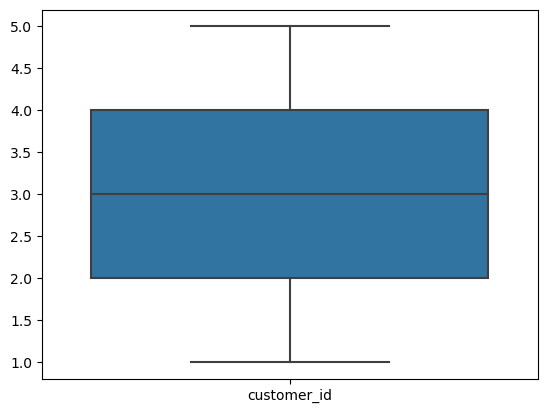

In [12]:
sns.boxplot(combined)

<Axes: >

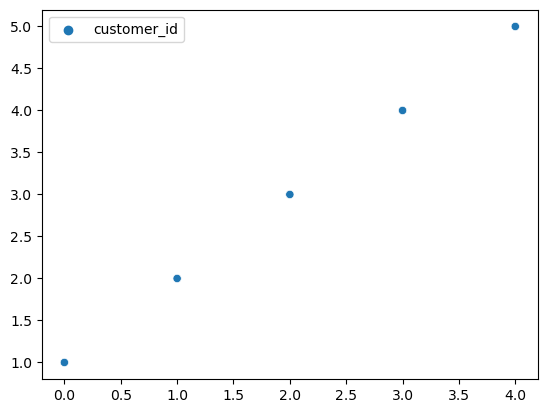

In [13]:
sns.scatterplot(combined)

<Axes: >

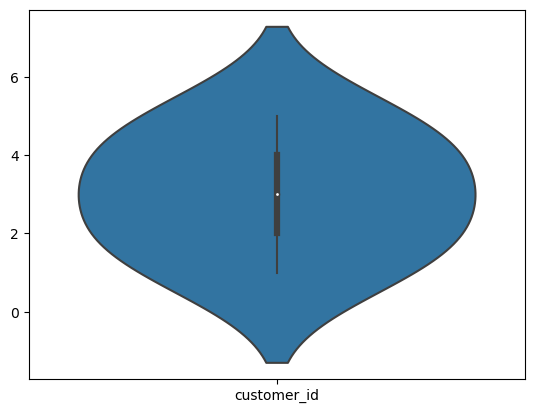

In [14]:
sns.violinplot(combined)

/tmp/ipykernel_20/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

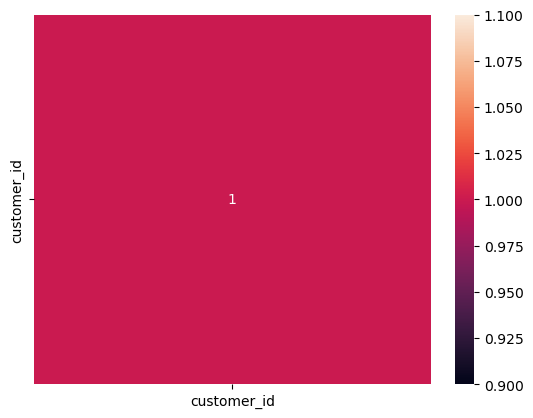

In [15]:
sns.heatmap(combined.corr(),annot=True)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


<Axes: >

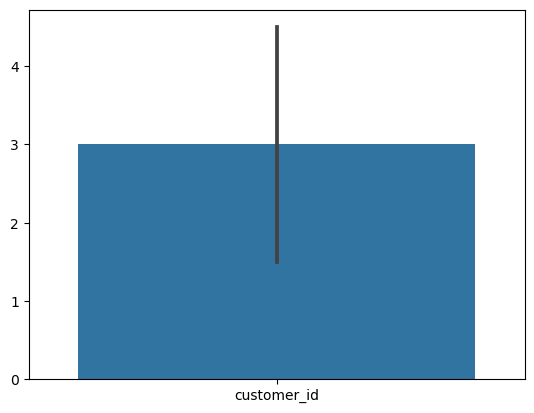

In [16]:
sns.barplot(combined)

<Axes: >

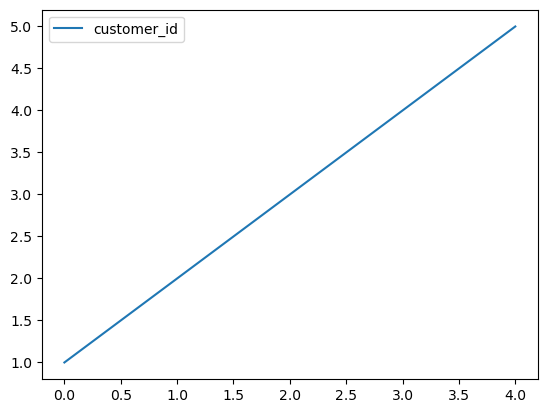

In [17]:
sns.lineplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


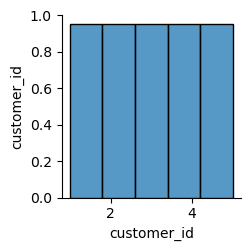

In [18]:
sns.pairplot(combined)

<Axes: ylabel='Density'>

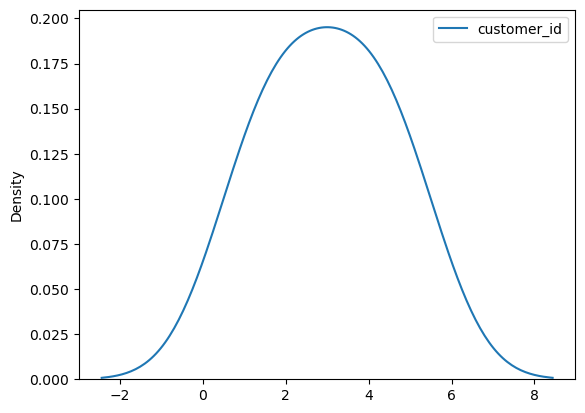

In [19]:
sns.kdeplot(combined)

In [20]:
cat_cols = combined.select_dtypes(include='object')

In [21]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf
881|1291|20|131|4|10.37801657     1
623|1229|21|110|3|-0.303669794    1
542|1243|20|179|2|-0.303622078    1
349|1389|20|112|4|-0.303624771    1
218|1154|20|168|1|-0.303630424    1
                                 ..
166|1026|20|181|2|-0.235381391    1
426|1396|20|135|4|-0.235391709    1
746|1056|20|144|3|-0.236855857    1
306|1259|21|168|2|-0.23773725     1
933|1447|22|192|3|-0.184480008    1
Name: product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf, Length: 937, dtype: int64
__________________________________________________
product_id
10 15 70 30 77 890 194 88 915 926 1028 190 452 916 891 456 904 965 404 11 977 414 119 659 52 406 94 128 459 145       1
5 9 70 456 414 404 452 194 119 190 890 406 116 11 459 926 426 453 405 891 77 915 904 916 52 425 659 965 1028 94       1
80 2 7 452 456 116 404 414 77 890 194 406 926 915 88 1028 190 459 916 891 426 904 977 453 405 965 11 52 659 425       1
6

In [22]:
num_cols = combined.select_dtypes(include='number')

In [23]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

customer_id
1.0    1
2.0    1
3.0    1
4.0    1
5.0    1
Name: customer_id, dtype: int64
__________________________________________________


In [24]:
combined.shape

(942, 3)

In [25]:
combined['product_id'].value_counts()

10 15 70 30 77 890 194 88 915 926 1028 190 452 916 891 456 904 965 404 11 977 414 119 659 52 406 94 128 459 145       1
5 9 70 456 414 404 452 194 119 190 890 406 116 11 459 926 426 453 405 891 77 915 904 916 52 425 659 965 1028 94       1
80 2 7 452 456 116 404 414 77 890 194 406 926 915 88 1028 190 459 916 891 426 904 977 453 405 965 11 52 659 425       1
600 400 1 12 404 414 406 203 116 77 459 890 426 405 453 926 194 915 1028 88 190 891 425 916 904 977 418 11 965 417    1
70 60 20 56 119 81 328 972 495 174 813 37 801 494 163 165 172 177 29 329 975 491 493 245 38 193 79 188 34 178         1
Name: product_id, dtype: int64

In [26]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

customer_id    2.0
dtype: float64


/tmp/ipykernel_20/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_20/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_20/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [27]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [28]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

/tmp/ipykernel_20/1551434999.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


In [29]:
combined_new.shape

(942, 3)

In [30]:
combined['product_id']=combined['product_id'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_20/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


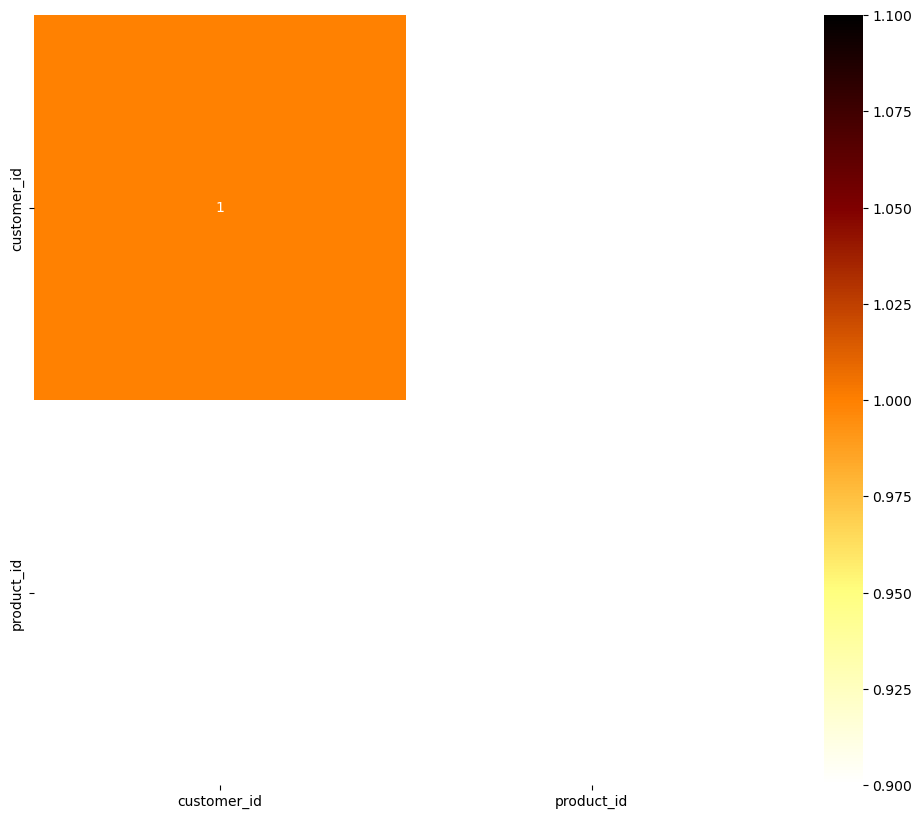

In [31]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

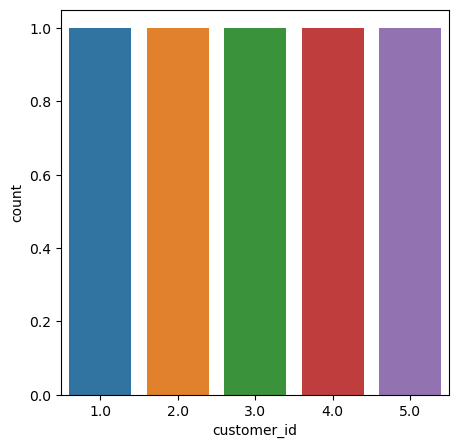

In [32]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

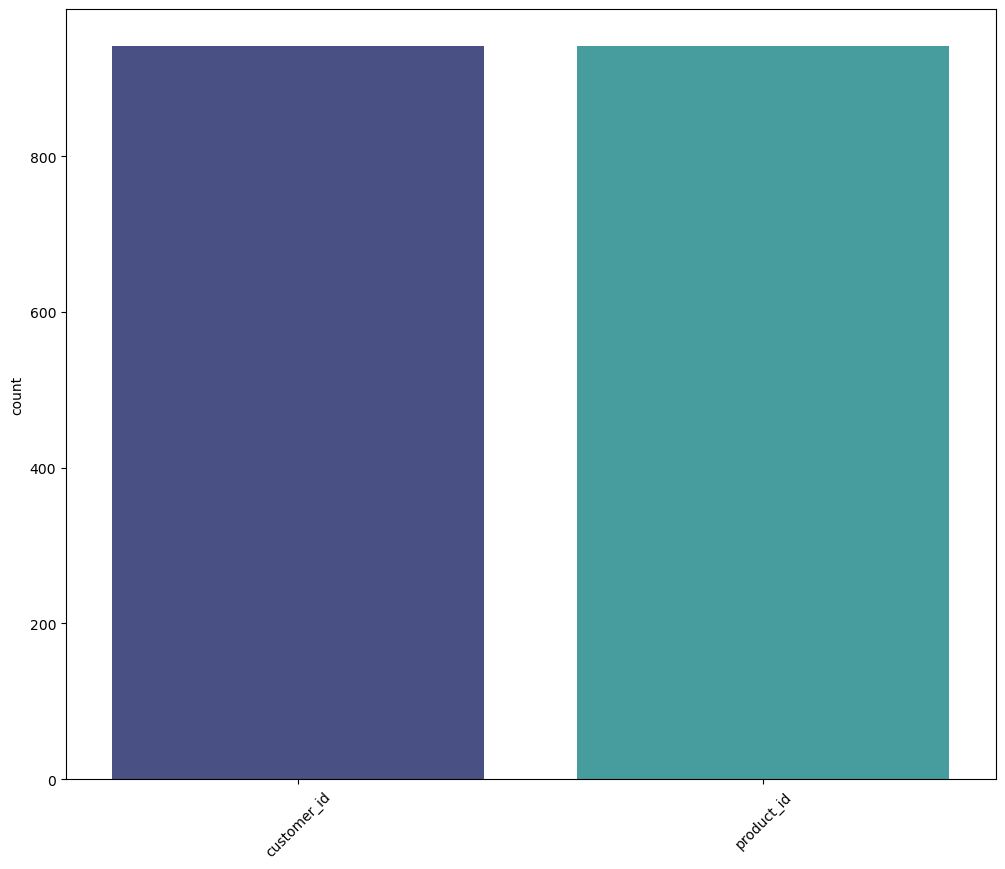

In [33]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

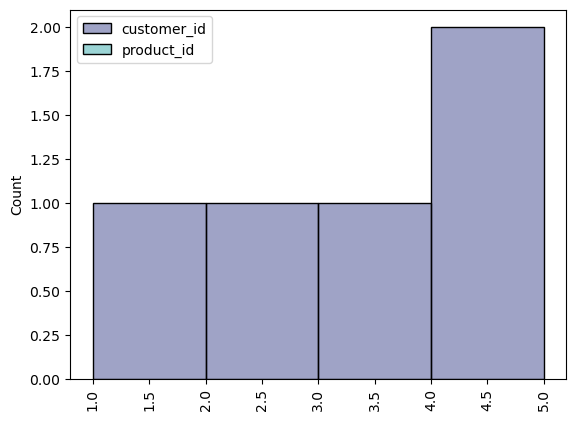

In [34]:
sns.histplot(data=combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


(array([0, 1]), [Text(0, 0, 'customer_id'), Text(1, 0, 'product_id')])

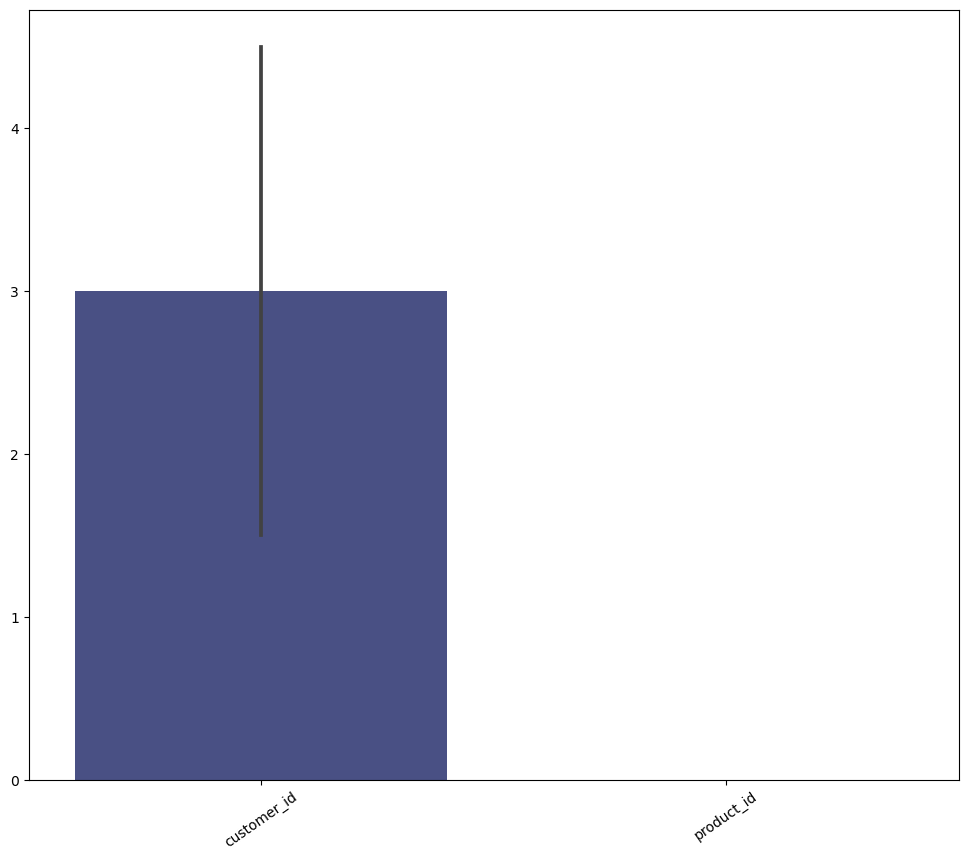

In [35]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako')
plt.xticks(rotation=35)

In [36]:
combined['product_id'].unique()

array([nan])

In [37]:
combined.groupby('product_id').apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_20/1283403792.py:1: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('product_id').apply(lambda x:x.fillna(x.mode()[0]))


,product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf,customer_id,product_id
product_id,,,


In [38]:
combined.head()

,product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf,customer_id,product_id
0,881|1291|20|131|4|10.37801657,NaN,NaN
1,805|1224|20|131|3|10.17792519,NaN,NaN
2,892|1089|20|146|1|10.00824289,NaN,NaN
3,841|1224|20|131|3|7.698361552,NaN,NaN
4,830|1089|20|131|1|7.35367762,NaN,NaN


In [39]:
combined['product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf'].value_counts()

881|1291|20|131|4|10.37801657     1
623|1229|21|110|3|-0.303669794    1
542|1243|20|179|2|-0.303622078    1
349|1389|20|112|4|-0.303624771    1
218|1154|20|168|1|-0.303630424    1
                                 ..
166|1026|20|181|2|-0.235381391    1
426|1396|20|135|4|-0.235391709    1
746|1056|20|144|3|-0.236855857    1
306|1259|21|168|2|-0.23773725     1
933|1447|22|192|3|-0.184480008    1
Name: product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf, Length: 937, dtype: int64

In [40]:
cat_cols

,product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf,product_id
0,881|1291|20|131|4|10.37801657,NaN
1,805|1224|20|131|3|10.17792519,NaN
2,892|1089|20|146|1|10.00824289,NaN
3,841|1224|20|131|3|7.698361552,NaN
4,830|1089|20|131|1|7.35367762,NaN
...,...,...
0,NaN,10 15 70 30 77 890 194 88 915 926 1028 190 452...
1,NaN,5 9 70 456 414 404 452 194 119 190 890 406 116...
2,NaN,80 2 7 452 456 116 404 414 77 890 194 406 926 ...
3,NaN,600 400 1 12 404 414 406 203 116 77 459 890 42...


In [41]:
num_cols

,customer_id
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
0,1.0
1,2.0
2,3.0
3,4.0


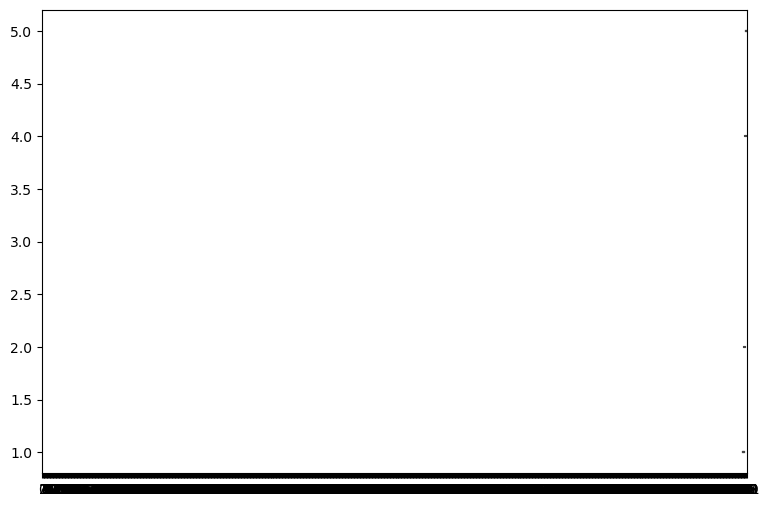

In [42]:
plt.figure(figsize=(15,20))
iterator=1
for i in num_cols:
    plt.subplot(4,2,iterator)
    sns.boxplot(combined[i])
    iterator+=1
plt.tight_layout()

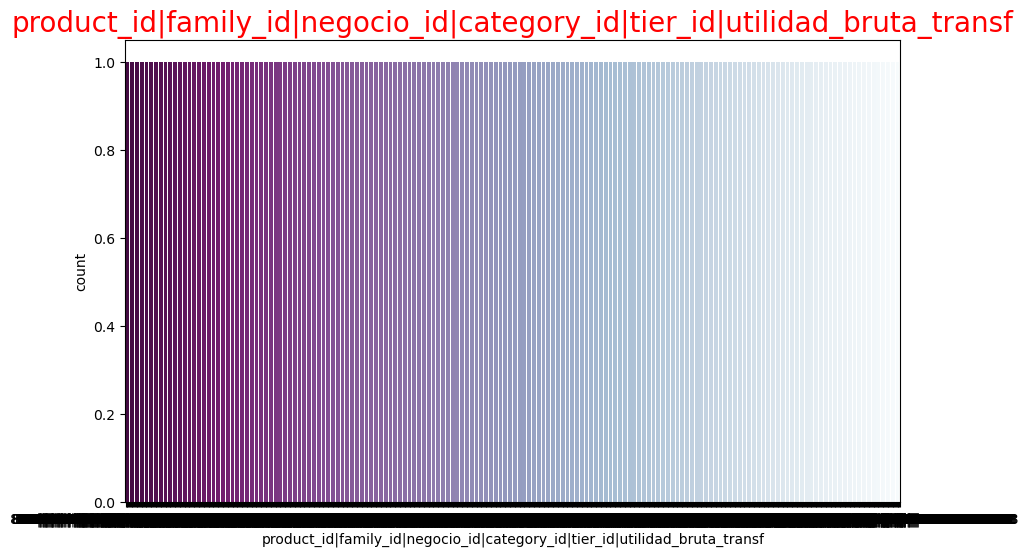

In [43]:
plt.figure(figsize=(10,6))
sns.countplot(data=combined,x='product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf',palette='BuPu_r')
plt.title('product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf',size=20,color='Red')
plt.show()

In [44]:
combined['product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf'].value_counts(normalize=True)*100

881|1291|20|131|4|10.37801657     0.106724
623|1229|21|110|3|-0.303669794    0.106724
542|1243|20|179|2|-0.303622078    0.106724
349|1389|20|112|4|-0.303624771    0.106724
218|1154|20|168|1|-0.303630424    0.106724
                                    ...   
166|1026|20|181|2|-0.235381391    0.106724
426|1396|20|135|4|-0.235391709    0.106724
746|1056|20|144|3|-0.236855857    0.106724
306|1259|21|168|2|-0.23773725     0.106724
933|1447|22|192|3|-0.184480008    0.106724
Name: product_id|family_id|negocio_id|category_id|tier_id|utilidad_bruta_transf, Length: 937, dtype: float64